In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stat


name_dictionary = {
    'Avatars K5': 'avatarsk5',
    'Avatars K10': 'avatarsk10',
    'CTGAN': 'ctgan',
    'Gaussian Copula': 'gaussiancopula',
    'Synthpop': 'synthpop',
    'TVAE': 'tvae'
}
target_cancer = 'NSCLC' 
seeds = [0,1,2,3,42]
# datasets = [f'avatarsk5_{seed}', f'avatarsk10_{seed}',f'ctgan_{seed}',f'gaussiancopula_{seed}',f'synthpop_{seed}',f'tvae_{seed}']
MetaScore = {}

In [2]:
# Giả sử bạn chọn 1 loại ung thư cụ thể, ví dụ 'NSCLC'


rows_all_seeds = []

# Duyệt qua từng phương pháp
for name, pathname in name_dictionary.items():
    for seed in seeds:
        try:
            # 1. Đọc điểm Clinical
            uni_clinical_path = f'../{target_cancer}/BroadUtility/UniClinicalSimi/UniClinicalSimi_{seed}/Detail_score_{pathname}_{seed}.csv'
            uni_clinical_df = pd.read_csv(uni_clinical_path)
            score_clinical_1_seed = uni_clinical_df["Score"].fillna(0).mean()

            # 2. Đọc điểm Omic
            uni_omic_path = f'../{target_cancer}/BroadUtility/UniTranscriptomicsSimi/UniTranscriptomicsSimi_{seed}/Detail_score_{pathname}_{seed}.csv'
            uni_omic_df = pd.read_csv(uni_omic_path)
            score_omic_1_seed = uni_omic_df["Score"].fillna(0).mean()

            # 3. Tính điểm tổng hợp cho seed này
            overall_score_seed = 0.5 * (score_omic_1_seed + score_clinical_1_seed)
            
            # Lưu lại thông tin định danh: Model và Seed cụ thể
            rows_all_seeds.append({
                'Model': name,
                'Seed': seed,
                'Value': overall_score_seed,
                'Identifier': f"{name}_Seed_{seed}"
            })
        except Exception as e:
            print(f"Lỗi tại {name} seed {seed}: {e}")

df_uni_seeds = pd.DataFrame(rows_all_seeds)

df_uni_seeds['Rank'] = df_uni_seeds['Value'].rank(ascending=False, method='min').astype(int)

uni_rank_derived_score = {}
for model_name in name_dictionary.keys():
    avg_rank = df_uni_seeds[df_uni_seeds['Model'] == model_name]['Rank'].mean()
    uni_rank_derived_score[model_name] = avg_rank


MetaScore['UnivariateScore'] = uni_rank_derived_score

In [3]:
rows_bi_seeds = []

# Duyệt qua từng phương pháp
for name, pathname in name_dictionary.items():
    for seed in seeds:
        try:
            # 1. Load dữ liệu Bivariate Clinical (.npy)
            bi_clinical_path = f'../{target_cancer}/BroadUtility/PairwiseClinical/PairwiseClinical_{seed}/bivariate_{pathname}_{seed}_all.npy'
            bi_clinical_data = np.load(bi_clinical_path)
            score_clinical_1_seed = np.mean(bi_clinical_data)

            # 2. Load dữ liệu Bivariate Omic (.npy)
            bi_omic_path = f'../{target_cancer}/BroadUtility/PairwiseTranscriptomicsSimi/PairwiseTranscriptomicsSimi_{seed}/{pathname}_{seed}_all.npy'
            bi_omic_data = np.load(bi_omic_path)
            score_omic_1_seed = np.mean(bi_omic_data)

            cross_path = f'../{target_cancer}/BroadUtility/PairwiseCrossGroup/CrossGroup_{seed}/{pathname}_{seed}_cross_group_full.csv'
            cross_df = pd.read_csv(cross_path)
            score_cross = cross_df['Score'].fillna(0).mean()

            # 3. Tính điểm trung bình cộng cho seed này
            overall_score_seed = (1/3) * (score_omic_1_seed + score_clinical_1_seed+score_cross)
            
            # Lưu vào danh sách để ranking
            rows_bi_seeds.append({
                'Model': name,
                'Seed': seed,
                'Value': overall_score_seed,
                'Identifier': f"{name}_Seed_{seed}"
            })
        except FileNotFoundError:
            print(f"Warning: File not found for {name} seed {seed}")
        except Exception as e:
            print(f"Error processing {name} seed {seed}: {e}")

In [4]:
# Tạo DataFrame phẳng cho 30 mẫu (6 models * 5 seeds)
df_bi_seeds = pd.DataFrame(rows_bi_seeds)

# --- RANKING 30 KẾT QUẢ ---
# Điểm tương quan (Similarity) càng cao thì hạng càng nhỏ (càng tốt)
df_bi_seeds['Rank'] = df_bi_seeds['Value'].rank(ascending=False, method='min').astype(int)

# --- TÍNH DERIVED SCORE CHO METASCORE ---
# Tính trung bình hạng (Mean Rank) của các seed cho mỗi Model
bi_rank_derived_score = {}
for model_name in name_dictionary.keys():
    # Lấy trung bình hạng của model đó qua 5 seeds
    avg_rank = df_bi_seeds[df_bi_seeds['Model'] == model_name]['Rank'].mean()
    bi_rank_derived_score[model_name] = avg_rank

# Cập nhật vào MetaScore
MetaScore['BivariateScore'] = bi_rank_derived_score

In [5]:
rows_gcs_seeds = []
all_tools = name_dictionary.keys()

try:
    # Đọc file điểm GCS (thường file này chứa các cột là Tool_Seed)
    gcs_df = pd.read_csv(f"../{target_cancer}/NarrowUtility/DGE/PCS/pcs_score.csv", index_col=0)
    
    # Duyệt qua từng phương pháp và từng seed
    for name, pathname in name_dictionary.items():
        for seed in seeds:
            # Xác định tên cột tương ứng trong file pcs_score.csv
            # Dựa vào cấu trúc code trước của bạn, tên cột thường là {name} hoặc {name}_{seed}
            # Ở đây tôi giả định bạn cần lấy giá trị cụ thể của từng seed
            
            # Giả sử file pcs_score.csv của bạn có các cột dạng: 'CTGAN_0', 'CTGAN_1', ...
            # Nếu cột chỉ đơn giản là 'CTGAN', chúng ta lấy giá trị đó cho mọi seed (hoặc báo thiếu)
            col_name = f"{name}_{seed}" 
            
            if col_name in gcs_df.columns:
                score_value = gcs_df[col_name].mean() # Trung bình các gene trong seed đó
            elif name in gcs_df.columns:
                # Nếu file không chia seed mà chỉ có tên model chung
                score_value = gcs_df[name].mean()
            else:
                score_value = 0.0 # Gán 0 nếu không tìm thấy dữ liệu
                
            rows_gcs_seeds.append({
                'Model': name,
                'Seed': seed,
                'Value': score_value,
                'Identifier': f"{name}_Seed_{seed}"
            })

except FileNotFoundError:
    print(f"Warning: File not found for {target_cancer}")
    # Gán 0 cho toàn bộ nếu thiếu file
    for name in all_tools:
        for seed in seeds:
            rows_gcs_seeds.append({'Model': name, 'Seed': seed, 'Value': 0.0})

In [6]:
# Tạo DataFrame phẳng cho 30 mẫu
df_gcs_seeds = pd.DataFrame(rows_gcs_seeds)

# --- RANKING 30 KẾT QUẢ ---
# Điểm GCS càng cao (gần 1) càng tốt
df_gcs_seeds['Rank'] = df_gcs_seeds['Value'].rank(ascending=False, method='min').astype(int)

# --- TÍNH DERIVED SCORE CHO METASCORE ---
gcs_rank_derived_score = {}
for model_name in all_tools:
    # Lấy trung bình hạng của model đó qua các seed
    avg_rank = df_gcs_seeds[df_gcs_seeds['Model'] == model_name]['Rank'].mean()
    gcs_rank_derived_score[model_name] = avg_rank

# Cập nhật vào MetaScore
MetaScore['DGE'] = gcs_rank_derived_score

In [7]:
rows_pcs_seeds = []
all_tools = name_dictionary.keys()

try:
    # Đọc file điểm PCS của GSEA
    pcs_df = pd.read_csv(f"../{target_cancer}/NarrowUtility/GSEA/PCS_Jiter/pcs_score.csv", index_col=0)
    
    # Duyệt qua từng phương pháp và từng seed để lấy 30 kết quả
    for name, pathname in name_dictionary.items():
        for seed in seeds:
            # Xác định tên cột. Giả định định dạng cột là '{Model}_{Seed}' (VD: 'CTGAN_0')
            # Nếu file của bạn dùng định dạng khác, hãy điều chỉnh f-string này
            col_name = f"{name}_{seed}" 
            
            if col_name in pcs_df.columns:
                # Lấy trung bình điểm PCS của các Pathway trong seed đó
                score_value = pcs_df[col_name].mean()
            elif name in pcs_df.columns:
                # Backup: Nếu file chỉ có tên Model chung (đã trung bình các seed)
                score_value = pcs_df[name].mean()
            else:
                # Gán 0 nếu tool/seed đó không xuất hiện trong kết quả GSEA
                score_value = 0.0
                
            rows_pcs_seeds.append({
                'Model': name,
                'Seed': seed,
                'Value': score_value,
                'Identifier': f"{name}_Seed_{seed}"
            })

except FileNotFoundError:
    print(f"Warning: File not found for {target_cancer} at GSEA path.")
    # Fallback gán 0 nếu thiếu file dữ liệu
    for name in all_tools:
        for seed in seeds:
            rows_pcs_seeds.append({'Model': name, 'Seed': seed, 'Value': 0.0})



In [8]:
# Tạo DataFrame phẳng 30 thực thể
df_pcs_seeds = pd.DataFrame(rows_pcs_seeds)

# --- RANKING 30 KẾT QUẢ ---
# Điểm PCS càng cao (similarity giữa dữ liệu thật và giả về Pathway) càng tốt
df_pcs_seeds['Rank'] = df_pcs_seeds['Value'].rank(ascending=False, method='min').astype(int)

# --- TÍNH DERIVED SCORE (AVERAGE RANK) CHO METASCORE ---
pcs_rank_derived_score = {}
for model_name in all_tools:
    # Tính trung bình hạng của 5 seeds để đại diện cho Model
    avg_rank = df_pcs_seeds[df_pcs_seeds['Model'] == model_name]['Rank'].mean()
    pcs_rank_derived_score[model_name] = avg_rank

# Lưu vào MetaScore cho tiêu chí GSEA
MetaScore['GSEA'] = pcs_rank_derived_score

In [9]:
rows_ssgsea_seeds = []
all_tools = name_dictionary.keys()

# Duyệt qua từng phương pháp và từng seed để lấy 30 kết quả
for name, pathname in name_dictionary.items():
    for seed in seeds:
        try:
            # Đường dẫn file ssGSEA cụ thể cho từng seed
            file_path = f'../{target_cancer}/NarrowUtility/ssGSEA/KSStatistic/Seed_{seed}/Detail_score_{pathname}_{seed}.csv'
            
            # Đọc dữ liệu
            df = pd.read_csv(file_path)
            
            # Tính điểm trung bình (thường là KS Statistic hoặc Similarity score)
            # fillna(0) để đảm bảo các pathway không tính toán được sẽ nhận điểm 0
            score_ssgsea_1_seed = df["Score"].fillna(0).mean()
            
            rows_ssgsea_seeds.append({
                'Model': name,
                'Seed': seed,
                'Value': score_ssgsea_1_seed,
                'Identifier': f"{name}_Seed_{seed}"
            })
            
        except FileNotFoundError:
            print(f"Warning: File not found for {name} seed {seed} at {file_path}")
            rows_ssgsea_seeds.append({'Model': name, 'Seed': seed, 'Value': 0.0})
        except Exception as e:
            print(f"Error at {name} seed {seed}: {e}")
            rows_ssgsea_seeds.append({'Model': name, 'Seed': seed, 'Value': 0.0})


In [10]:

# Tạo DataFrame phẳng cho 30 thực thể
df_ssgsea_seeds = pd.DataFrame(rows_ssgsea_seeds)

# --- RANKING 30 KẾT QUẢ ---
# Giả định: Score càng cao (Similarity) càng tốt -> rank(ascending=False)
df_ssgsea_seeds['Rank'] = df_ssgsea_seeds['Value'].rank(ascending=False, method='min').astype(int)

# --- TÍNH DERIVED SCORE (AVERAGE RANK) CHO METASCORE ---
ssGSEA_rank_derived_score = {}
for model_name in all_tools:
    # Lấy trung bình hạng của 5 seeds để đại diện cho Model trong MetaScore
    avg_rank = df_ssgsea_seeds[df_ssgsea_seeds['Model'] == model_name]['Rank'].mean()
    ssGSEA_rank_derived_score[model_name] = avg_rank

# Lưu vào MetaScore
MetaScore['ssGSEA'] = ssGSEA_rank_derived_score


In [30]:
rows_cell_seeds = []
all_tools = name_dictionary.keys()

try:
    # Xử lý đường dẫn linh hoạt cho từng loại ung thư (ccRCC/Melanoma có path khác NSCLC một chút)
    if target_cancer == 'NSCLC':
        path = f"../NSCLC/NarrowUtility/CellDeco/AitchisonDistance/Score.csv"
    else:
        path = f"../{target_cancer}/NarrowUtility/CellDecovo/AitchisonDistance/Score.csv"
    
    # Đọc file điểm (File này thường có index là Tool_Seed và 1 cột điểm)
    # .T.mean() hoặc xử lý trực tiếp tùy vào cấu trúc file Score.csv của bạn
    score_df = pd.read_csv(path, index_col=0)
    
    # Duyệt qua từng phương pháp và từng seed
    for name in all_tools:
        for seed in seeds:
            if name in score_df.index:
                val = score_df.loc[name, str(seed)]
            else:
                # Nếu không tìm thấy, gán một khoảng cách rất lớn (phạt nặng)
                val = 999.0 
                
            rows_cell_seeds.append({
                'Model': name,
                'Seed': seed,
                'Value': val,
                'Identifier': f"{name}_Seed_{seed}"
            })

except FileNotFoundError:
    print(f"Warning: File not found for {target_cancer}")
    for name in all_tools:
        for seed in seeds:
            rows_cell_seeds.append({'Model': name, 'Seed': seed, 'Value': 999.0})



In [31]:
# Tạo DataFrame 30 thực thể
df_cell_seeds = pd.DataFrame(rows_cell_seeds)

# --- RANKING 30 KẾT QUẢ ---
# QUAN TRỌNG: Aitchison Distance càng NHỎ càng tốt 
# nên ascending=True để giá trị nhỏ nhất nhận Rank 1
df_cell_seeds['Rank'] = df_cell_seeds['Value'].rank(ascending=False, method='min').astype(int)

# --- TÍNH DERIVED SCORE (AVERAGE RANK) ---
aitchinson_rank_derived_score = {}
for model_name in all_tools:
    avg_rank = df_cell_seeds[df_cell_seeds['Model'] == model_name]['Rank'].mean()
    aitchinson_rank_derived_score[model_name] = avg_rank

# Cập nhật vào MetaScore
MetaScore['Cell Deconvolution'] = aitchinson_rank_derived_score

In [13]:
rows_sa_seeds = []
algo = ["Avatars K5", "Avatars K10", "CTGAN", "Gaussian Copula", "Synthpop", 'TVAE']

# Duyệt qua từng seed để lấy kết quả
for seed in seeds:
    try:
        # Xác định đường dẫn file dựa trên loại ung thư
        if target_cancer == 'ccRCC':
            base_path = f"../ccRCC/NarrowUtility/SA/SA_Nivo_Benefit/Seed_{seed}"
        elif target_cancer == 'Melanoma':
            base_path = f"../Melanoma/NarrowUtility/SA/CRPR_PD/Seed_{seed}"
        else: # NSCLC
            base_path = f"../NSCLC/NarrowUtility/SA/CRPR_PD/Seed_{seed}"

        # Đọc điểm OS (Overall Survival) và PFS (Progression-Free Survival)
        df_os = pd.read_csv(f"{base_path}/Scores.csv").iloc[1:,:]
        df_pfs = pd.read_csv(f"{base_path}/Scores_PFS.csv").iloc[1:,:]
        
        # Điền 0 cho các giá trị thiếu (nếu model không hội tụ)
        df_os['C-index_score'] = pd.to_numeric(df_os['C-index_score']).fillna(0)
        df_pfs['C-index_score'] = pd.to_numeric(df_pfs['C-index_score']).fillna(0)

        # Tính toán điểm trung bình OS và PFS cho từng model trong seed này
        scores_os = df_os['C-index_score'].values
        scores_pfs = df_pfs['C-index_score'].values
        combined_scores = (scores_os + scores_pfs) / 2

        # Lưu kết quả của 6 model trong seed hiện tại
        for i, name in enumerate(algo):
            rows_sa_seeds.append({
                'Model': name,
                'Seed': seed,
                'Value': combined_scores[i],
                'Identifier': f"{name}_Seed_{seed}"
            })

    except Exception as e:
        print(f"Error processing {target_cancer} seed {seed}: {e}")
        # Nếu lỗi (thiếu file), gán điểm 0 cho tất cả models của seed đó
        for name in algo:
            rows_sa_seeds.append({'Model': name, 'Seed': seed, 'Value': 0.0, 'Identifier': f"{name}_Seed_{seed}"})

In [14]:
# Tạo DataFrame phẳng cho 30 mẫu
df_sa_seeds = pd.DataFrame(rows_sa_seeds)

# --- RANKING 30 KẾT QUẢ ---
# C-index càng CAO càng tốt -> ascending=False
df_sa_seeds['Rank'] = df_sa_seeds['Value'].rank(ascending=False, method='min').astype(int)

# --- TÍNH DERIVED SCORE (AVERAGE RANK) CHO METASCORE ---
cindex_rank_derived_score = {}
for name in name_dictionary.keys():
    # Tính trung bình hạng từ 5 seeds của mỗi model
    avg_rank = df_sa_seeds[df_sa_seeds['Model'] == name]['Rank'].mean()
    cindex_rank_derived_score[name] = avg_rank

# Cập nhật vào MetaScore
MetaScore['Survival Analysis'] = cindex_rank_derived_score

In [15]:

rows_privacy_seeds = []
all_tools = name_dictionary.keys()

try:
    # Đọc file điểm Privacy tổng thể cho loại ung thư mục tiêu
    # File này thường có index là Tool_Seed (ví dụ: 'CTGAN_0')
    privacy_path = f'../FigurePrivacy/overal_privacy_score_{target_cancer}.csv'
    privacy_df = pd.read_csv(privacy_path, index_col=0)
    
    # Nếu file của bạn đang ở dạng ngang (Tool_Seed ở columns), ta cần Transpose (.T)
    # Nếu Tool_Seed đã ở index thì không cần
    if any("_" in str(col) for col in privacy_df.columns):
        privacy_df = privacy_df.T

    # Duyệt qua từng phương pháp và từng seed để lấy 30 kết quả
    for name in all_tools:
        for seed in seeds:
            # Xác định mã định danh Tool_Seed
            col_identifier = f"{name}_{seed}"
            
            if col_identifier in privacy_df.index:
                score_value = privacy_df.loc[col_identifier].mean()
            elif name in privacy_df.index:
                # Backup nếu file chỉ có tên model chung
                score_value = privacy_df.loc[name].mean()
            else:
                # Gán điểm 0 nếu không có dữ liệu (rất nguy hiểm về privacy)
                score_value = 0.0
                
            rows_privacy_seeds.append({
                'Model': name,
                'Seed': seed,
                'Value': score_value,
                'Identifier': col_identifier
            })

except FileNotFoundError:
    print(f"Warning: Privacy file not found for {target_cancer}")
    for name in all_tools:
        for seed in seeds:
            rows_privacy_seeds.append({'Model': name, 'Seed': seed, 'Value': 0.0})

In [16]:
# Tạo DataFrame phẳng cho 30 thực thể
df_privacy_seeds = pd.DataFrame(rows_privacy_seeds)

# --- RANKING 30 KẾT QUẢ ---
# Điểm Privacy càng cao càng an toàn -> ascending=False
df_privacy_seeds['Rank'] = df_privacy_seeds['Value'].rank(ascending=False, method='min').astype(int)

# --- TÍNH DERIVED SCORE (AVERAGE RANK) ---
privacy_rank_derived_score = {}
for model_name in all_tools:
    # Lấy trung bình hạng của 5 seeds để đưa vào MetaScore
    avg_rank = df_privacy_seeds[df_privacy_seeds['Model'] == model_name]['Rank'].mean()
    privacy_rank_derived_score[model_name] = avg_rank

# Cập nhật vào MetaScore cuối cùng
MetaScore['Privacy'] = privacy_rank_derived_score

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

DATASET_COLORS = {
    "Origin": "#4d4d4d",
    "Avatars K5": "#66c2a5",  # greenish
    "Avatars K10": "#fc8d62",  # orange
    "CTGAN": "#8da0cb",  # blue
    "Gaussian Copula": "#e78ac3",  # pink
    "Synthpop": "#a6d854",  # lime
    "TVAE": "#ffd92f",  # yellow
}

COMPONENT_COLORS = {
    'Broad Utility': '#3498db',    # blue
    'Narrow Utility': '#9b59b6',   # purple
    'Privacy': '#e74c3c'           # red
}


def plot_weighted_composite_scores(
    MetaScore: dict,
    broad_weight: float = 0.3,
    narrow_weight: float = 0.5,
    privacy_weight: float = 0.2,
    figsize: tuple = (10, 7),
    save_path: str = None,
    orientation: str = 'horizontal',  # 'horizontal' or 'vertical'
):
    """
    Plot weighted composite scores as stacked bars.
    
    Args:
        MetaScore: dict with metric names as keys and dataset scores as values
        broad_weight: weight for broad utility (default: 0.3)
        narrow_weight: weight for narrow utility (default: 0.5)
        privacy_weight: weight for privacy (default: 0.2)
        figsize: figure size
        save_path: optional path to save figure
        orientation: 'horizontal' or 'vertical' (default: 'horizontal')
    """
    # Apply style
    try:
        plt.style.use(["science", "nature", "notebook"])
    except Exception:
        pass
    
    plt.rcParams.update({
        'text.usetex': False,
        'axes.edgecolor': '#333333',
        'xtick.minor.visible': False,
        'ytick.minor.visible': False,
        'xtick.top': False,
        'ytick.right': False,
    })
    
    # Create DataFrame from MetaScore
    df = pd.DataFrame(MetaScore)
    
    # Calculate weighted components
    df_final = pd.DataFrame()
    
    # Broad Utility = (Univariate + Bivariate) * broad_weight / 2
    broad_weighted = broad_weight * (1/2)
    df_final['Broad Utility'] = (
        df['UnivariateScore'] * broad_weighted + 
        df['BivariateScore'] * broad_weighted
    )
    
    # Narrow Utility = (DGE + GSEA + ssGSEA + Cell + Survival) * narrow_weight / 5
    narrow_weighted = narrow_weight * (1/5)
    narrow_metrics = ['DGE', 'GSEA', 'ssGSEA', 'Cell Deconvolution', 'Survival Analysis']
    df_final['Narrow Utility'] = df[narrow_metrics].sum(axis=1) * narrow_weighted
    
    # Privacy = Privacy * privacy_weight
    df_final['Privacy'] = df['Privacy'] * privacy_weight
    
    # Sort by total score
    df_final['Total'] = df_final.sum(axis=1)
    df_final = df_final.sort_values('Total', ascending=(orientation == 'vertical')).drop(columns='Total')
    
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Get dataset names and positions
    datasets = df_final.index.tolist()
    n_datasets = len(datasets)
    
    if orientation == 'horizontal':
        # Horizontal bars
        y = np.arange(n_datasets)
        height = 0.6
        left = np.zeros(n_datasets)
        
        for component in ['Broad Utility', 'Narrow Utility', 'Privacy']:
            values = df_final[component].values
            color = COMPONENT_COLORS[component]
            
            bars = ax.barh(
                y, 
                values, 
                height, 
                left=left, 
                label=component,
                color=color,
                edgecolor='white',
                linewidth=1.5,
                alpha=0.9
            )
            
            # Add value labels on bars (only if segment is wide enough)
            for i, (bar, val) in enumerate(zip(bars, values)):
                if val > 0.5:  # Only show label if segment is wide enough
                    ax.text(
                        left[i] + val / 2,
                        bar.get_y() + bar.get_height() / 2,
                        f'{val:.2f}',
                        ha='center',
                        va='center',
                        color='white',
                        fontsize=8,
                        fontweight='bold'
                    )
            
            left += values
        
        # Add total score at the end of each bar
        for i, total in enumerate(left):
            ax.text(
                total + 0.3,
                i,
                f'{total:.2f}',
                ha='left',
                va='center',
                color='black',
                fontsize=10,
                fontweight='bold'
            )
        
        # Styling
        ax.set_xlabel('Rank-derived score', fontsize=12, fontweight='bold')
        ax.set_ylabel('SDG methods', fontsize=12, fontweight='bold')
        # ax.set_title(
        #     'Weighted Composite Score: Broad vs Narrow vs Privacy',
        #     fontsize=14,
        #     fontweight='bold',
        #     pad=15
        # )
        
        # Y-axis: dataset names with colors
        ax.set_yticks(y)
        ax.set_yticklabels(
            [f"$\\mathbf{{{ds}}}$" for ds in datasets],
            fontsize=10
        )
        
        
        
        # Color y-tick labels according to dataset colors
        for i, (tick_label, dataset) in enumerate(zip(ax.get_yticklabels(), datasets)):
            color = DATASET_COLORS.get(dataset, '#333333')
            tick_label.set_color(color)
        
        # Grid
        ax.grid(axis='x', linestyle='--', linewidth=0.6, alpha=0.5)
        ax.set_axisbelow(True)
        
        # Set x-axis limit with padding for total labels
        ax.set_xlim(0, left.max() * 1.15)
        
    else:  # vertical
        x = np.arange(n_datasets)
        width = 0.6
        bottom = np.zeros(n_datasets)
        
        for component in ['Broad Utility', 'Narrow Utility', 'Privacy']:
            values = df_final[component].values
            color = COMPONENT_COLORS[component]
            
            bars = ax.bar(
                x, 
                values, 
                width, 
                bottom=bottom, 
                label=component,
                color=color,
                edgecolor='white',
                linewidth=1.5,
                alpha=0.9
            )
            
            # Add value labels on bars
            for i, (bar, val) in enumerate(zip(bars, values)):
                if val > 0.5:
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        bottom[i] + val / 2,
                        f'{val:.2f}',
                        ha='center',
                        va='center',
                        color='white',
                        fontsize=9,
                        fontweight='bold'
                    )
            
            bottom += values
        
        # Add total score on top
        for i, total in enumerate(bottom):
            ax.text(
                i,
                total + 0.3,
                f'{total:.2f}',
                ha='center',
                va='bottom',
                color='black',
                fontsize=10,
                fontweight='bold'
            )
        
        # Styling
        ax.set_ylabel('Rank-derived score', fontsize=12, fontweight='bold')
        ax.set_xlabel('SDG methods', fontsize=12, fontweight='bold')
        # ax.set_title(
        #     'Weighted Composite Score: Broad vs Narrow vs Privacy',
        #     fontsize=14,
        #     fontweight='bold',
        #     pad=15
        # )
        
        # X-axis: dataset names with colors
        ax.set_xticks(x)
        ax.set_xticklabels(
            [f"$\\mathbf{{{ds}}}$" for ds in datasets],
            rotation=45,
            ha='right',
            fontsize=10
        )
        
        # Color x-tick labels
        for i, (tick_label, dataset) in enumerate(zip(ax.get_xticklabels(), datasets)):
            color = DATASET_COLORS.get(dataset, '#333333')
            tick_label.set_color(color)
        
        # Grid
        ax.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.5)
        ax.set_axisbelow(True)
        
        # Set y-axis limit
        ax.set_ylim(0, bottom.max() * 1.1)
    
    # Legend (same for both orientations)
    # ax.legend(
    #     loc='upper right' if orientation == 'horizontal' else 'upper left',
    #     frameon=True,
    #     fontsize=10,
    #     fancybox=True,
    #     shadow=True
    # )
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Saved: {save_path}")
    
    plt.show()
    plt.close()
    
    # Return the final scores DataFrame
    df_final['Total'] = df_final.sum(axis=1)
    return fig, df_final.sort_values('Total', ascending=False)

✅ Saved: MetaScore_NSCLC.pdf


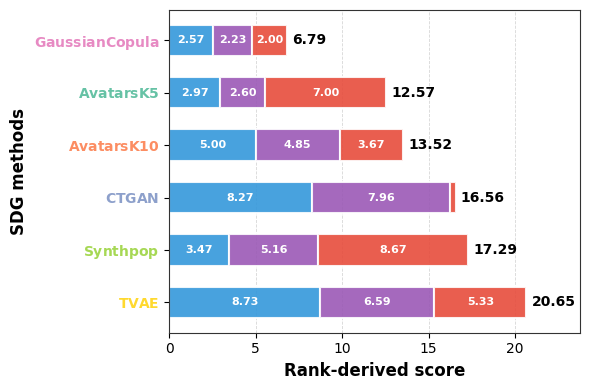

In [33]:
# Plot and get results
fig, results_df = plot_weighted_composite_scores(
    MetaScore=MetaScore,
    broad_weight=1/3,
    narrow_weight=1/3,
    privacy_weight=1/3,
    figsize=(6, 4),
     orientation='horizontal',
    save_path = 'MetaScore_NSCLC.pdf'
)

results_df.to_csv('MetaScore_NSCLC.csv', index = True)

In [34]:
import json

# Tên file muốn lưu
file_path = "MetaScore_NSCLC.json"

# Lưu dictionary
with open(file_path, 'w', encoding='utf-8') as f:
    json.dump(MetaScore, f, indent=4, ensure_ascii=False)